In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import xgboost
print("XGBoost version:", xgboost.__version__)
print("준비 완료!")

XGBoost version: 3.2.0
준비 완료!


In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# 11개 변수 전부 사용
features = df.columns.drop('quality').tolist()
X = df[features]
y = df['quality']

# 훈련 80% / 테스트 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("훈련 데이터:", len(X_train))
print("테스트 데이터:", len(X_test))

훈련 데이터: 1279
테스트 데이터: 320


In [5]:
# XGBoost 모델 만들기
xgb_model = XGBRegressor(
    n_estimators=300,    # 100 → 300으로 늘림
    learning_rate=0.05,  # 0.1 → 0.05로 줄임 (더 천천히 정밀하게 학습)
    max_depth=4,         # 5 → 4로 줄임 (과적합 방지)
    subsample=0.8,       # 매 트리마다 데이터 80%만 사용
    random_state=42
)

# 훈련 데이터로 학습
xgb_model.fit(X_train, y_train)

# 테스트 데이터로 예측
y_pred_xgb = xgb_model.predict(X_test)

# 성능 평가
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("=== XGBoost 결과 ===")
print(f"R²:   {r2_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")

print("\n=== 모델 성능 비교 ===")
print(f"다중회귀         R²: 0.388  RMSE: 0.633")
print(f"랜덤포레스트     R²: 0.539  RMSE: 0.549")
print(f"XGBoost         R²: {r2_xgb:.3f}  RMSE: {rmse_xgb:.3f}")

=== XGBoost 결과 ===
R²:   0.492
RMSE: 0.576

=== 모델 성능 비교 ===
다중회귀         R²: 0.388  RMSE: 0.633
랜덤포레스트     R²: 0.539  RMSE: 0.549
XGBoost         R²: 0.492  RMSE: 0.576


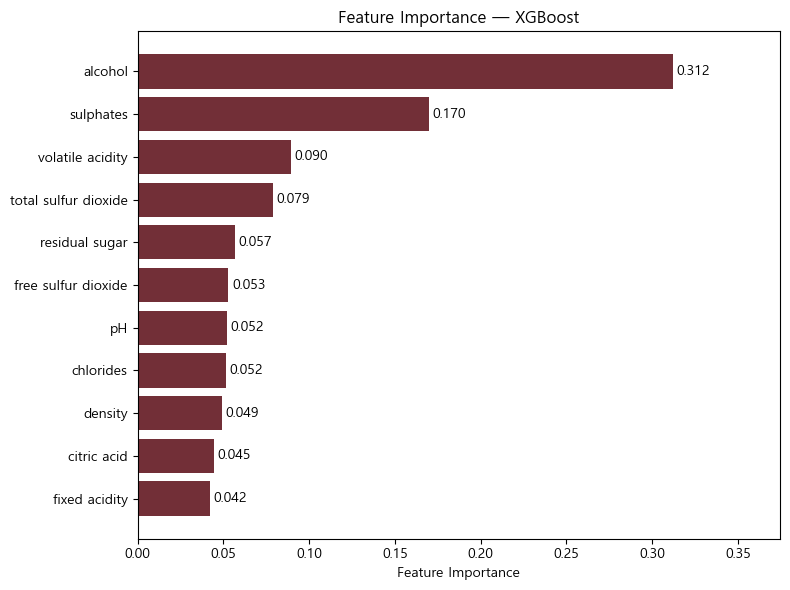

In [4]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df['feature'], importance_df['importance'],
        color='#722F37')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance — XGBoost')

for i, val in enumerate(importance_df['importance']):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center')

ax.set_xlim(0, max(importance_df['importance']) * 1.2)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import GridSearchCV

# 시도할 파라미터 조합 정의
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}

# GridSearchCV 설정
grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,           # 5번 교차검증
    scoring='r2',
    n_jobs=-1,      # 모든 CPU 코어 사용해서 빠르게
    verbose=1       # 진행 상황 출력
)

# 학습
grid_search.fit(X_train, y_train)

print("=== 최적 파라미터 ===")
print(grid_search.best_params_)
print(f"\n최적 R²: {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
=== 최적 파라미터 ===
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}

최적 R²: 0.407


In [7]:
# 최적 파라미터로 다시 학습
best_xgb = XGBRegressor(
    learning_rate=0.2,
    max_depth=5,
    n_estimators=100,
    random_state=42
)

best_xgb.fit(X_train, y_train)
y_pred_best = best_xgb.predict(X_test)

r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("=== 최적 파라미터 XGBoost 결과 ===")
print(f"R²:   {r2_best:.3f}")
print(f"RMSE: {rmse_best:.3f}")

print("\n=== 전체 모델 성능 비교 ===")
print(f"다중회귀              R²: 0.388  RMSE: 0.633")
print(f"랜덤포레스트          R²: 0.539  RMSE: 0.549")
print(f"XGBoost (기본)       R²: 0.463  RMSE: 0.593")
print(f"XGBoost (최적)       R²: {r2_best:.3f}  RMSE: {rmse_best:.3f}")

=== 최적 파라미터 XGBoost 결과 ===
R²:   0.459
RMSE: 0.594

=== 전체 모델 성능 비교 ===
다중회귀              R²: 0.388  RMSE: 0.633
랜덤포레스트          R²: 0.539  RMSE: 0.549
XGBoost (기본)       R²: 0.463  RMSE: 0.593
XGBoost (최적)       R²: 0.459  RMSE: 0.594
